In [1]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
import numpy as np
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline

from copy import deepcopy
# 設定中文顯示，載入字體: msjh.ttc (微軟正黑體)
font_path = 'msjh.ttc'
font_prop = font_manager.FontProperties(fname=font_path)
plt.rcParams['axes.unicode_minus'] = False    # 避免坐標軸負號顯示問題

In [2]:
# 生成資料
np.random.seed(42)
m = 100  # 筆數
X = 10 * np.random.rand(m, 1) - 5  # 隨機產生m筆X值
y = 0.5 * X ** 2 - X + 2 + 3 * np.random.randn(m, 1)  # 根據二次方程式計算y值

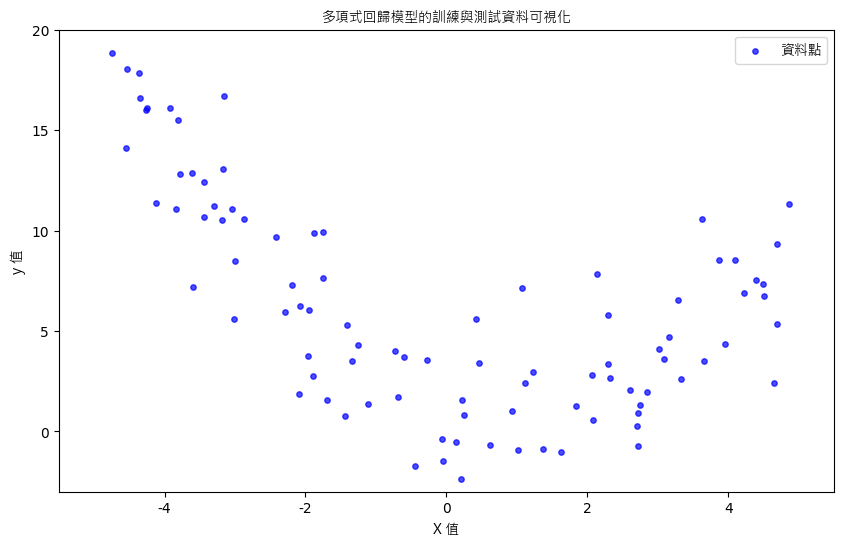

In [3]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color="blue", label="資料點", alpha=0.7, s=15)
plt.axis([-5.5, 5.5, -3, 20])

# 添加標題和標籤，全部加上 fontproperties=font_prop
plt.xlabel("X 值", fontproperties=font_prop)
plt.ylabel("y 值", fontproperties=font_prop)
plt.title("多項式回歸模型的訓練與測試資料可視化", fontproperties=font_prop)
plt.legend(prop=font_prop)
plt.show()

In [4]:
# 使用 train_test_split 將資料分為訓練集和測試集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42)

# 使用 PolynomialFeatures 進行多項式轉換
poly_features = make_pipeline(PolynomialFeatures(degree=50, include_bias=False),
                              StandardScaler())
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

# 使用 PolynomialFeatures 進行多項式轉換
poly_features_2 = make_pipeline(PolynomialFeatures(degree=2, include_bias=False),
                                 StandardScaler())
X_train_poly_2 = poly_features_2.fit_transform(X_train)
X_test_poly_2 = poly_features_2.transform(X_test)

In [5]:
# 建立線性回歸模型並訓練
lin_reg = SGDRegressor(penalty=None, max_iter=1, eta0=0.001)
lin_reg2 = SGDRegressor(penalty=None, max_iter=1, eta0=0.001)

n_epochs = 2000
best_valid_rmse = float('inf')
best_epoch = 0
train_errors, val_errors = [], []
for epoch in range(n_epochs):
    lin_reg.partial_fit(X_train_poly, y_train.ravel())
    lin_reg2.partial_fit(X_train_poly_2, y_train.ravel())
    y_test_predict = lin_reg.predict(X_test_poly)
    y_test_predict_2 = lin_reg2.predict(X_test_poly_2)
    train_error = root_mean_squared_error(y_train, lin_reg.predict(X_train_poly))
    val_error = root_mean_squared_error(y_test, y_test_predict)
    if val_error < best_valid_rmse:
        best_valid_rmse = val_error
        best_model = deepcopy(lin_reg)
        best_epoch = epoch
    train_errors.append(train_error)
    val_errors.append(val_error)

50次多項式回歸 - 訓練集 RMSE: 2.70, 測試集 RMSE: 7.24
2次多項式回歸 - 訓練集 RMSE: 2.83, 測試集 RMSE: 2.40


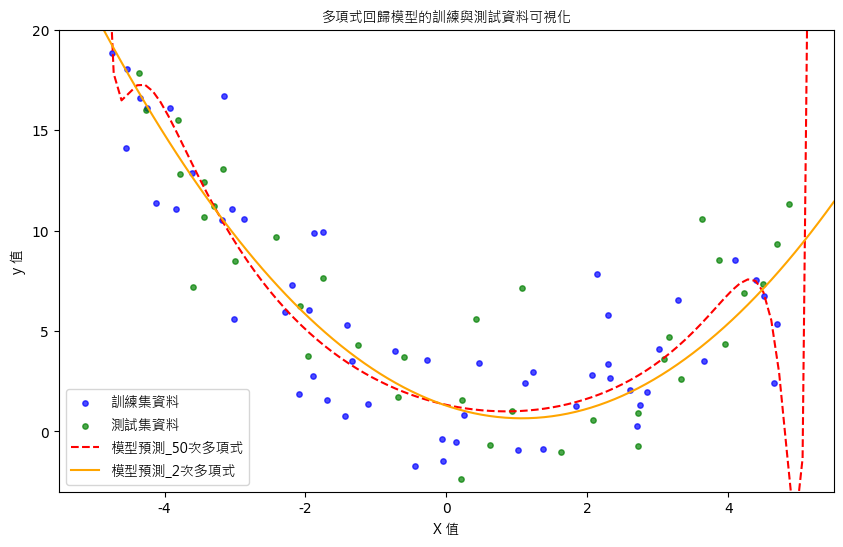

In [6]:
# 預測
y_train_pred = lin_reg.predict(X_train_poly)
y_test_pred = lin_reg.predict(X_test_poly)

# 計算均方誤差 (MSE)
train_rmse = root_mean_squared_error(y_train, y_train_pred)
test_rmse = root_mean_squared_error(y_test, y_test_pred)

# 預測
y_train_pred_2 = lin_reg2.predict(X_train_poly_2)
y_test_pred_2 = lin_reg2.predict(X_test_poly_2)

# 計算均方誤差 (MSE)
train_rmse_2 = root_mean_squared_error(y_train, y_train_pred_2)
test_rmse_2 = root_mean_squared_error(y_test, y_test_pred_2)

print(f"50次多項式回歸 - 訓練集 RMSE: {train_rmse:.2f}, 測試集 RMSE: {test_rmse:.2f}")
print(f"2次多項式回歸 - 訓練集 RMSE: {train_rmse_2:.2f}, 測試集 RMSE: {test_rmse_2:.2f}")

# 可視化結果
plt.figure(figsize=(10, 6))

# 訓練集資料點
plt.scatter(X_train, y_train, color="blue", label="訓練集資料", alpha=0.7, s=15)
# 測試集資料點
plt.scatter(X_test, y_test, color="green", label="測試集資料", alpha=0.7, s=15)

# 預測曲線
X_plot = np.linspace(-5.5, 5.5, 100).reshape(100, 1)
X_plot_poly = poly_features.transform(X_plot)
y_plot = lin_reg.predict(X_plot_poly)
# 改成虛線
plt.plot(X_plot, y_plot, color="red", label="模型預測_50次多項式", linestyle="--")

# 預測曲線_2
X_plot_poly_2 = poly_features_2.transform(X_plot)
y_plot_2 = lin_reg2.predict(X_plot_poly_2)
plt.plot(X_plot, y_plot_2, color="orange", label="模型預測_2次多項式")

plt.axis([-5.5, 5.5, -3, 20])

# 添加標題和標籤，全部加上 fontproperties=font_prop
plt.xlabel("X 值", fontproperties=font_prop)
plt.ylabel("y 值", fontproperties=font_prop)
plt.title("多項式回歸模型的訓練與測試資料可視化", fontproperties=font_prop)
plt.legend(prop=font_prop)
plt.show()

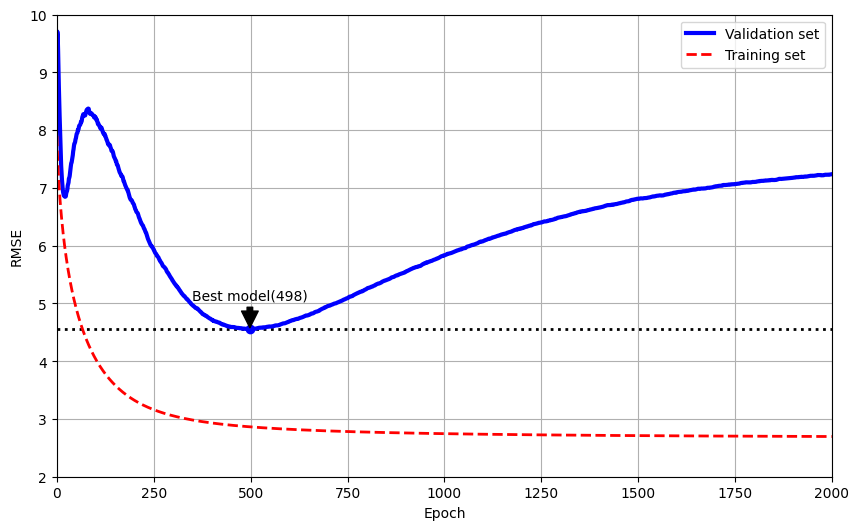

In [7]:
# extra code – this section generates and saves Figure 4–20
best_epoch = np.argmin(val_errors)
plt.figure(figsize=(10, 6))
plt.annotate(f'Best model({best_epoch})',
             xy=(best_epoch, best_valid_rmse),
             xytext=(best_epoch, best_valid_rmse + 0.5),
             ha="center",
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.plot([0, n_epochs], [best_valid_rmse, best_valid_rmse], "k:", linewidth=2)
plt.plot(val_errors, "b-", linewidth=3, label="Validation set")
plt.plot(best_epoch, best_valid_rmse, "bo")
plt.plot(train_errors, "r--", linewidth=2, label="Training set")
plt.legend(loc="upper right")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.axis([0, n_epochs, 2, 10])
plt.grid()
plt.savefig("early_stopping_plot.png")
plt.show()

In [8]:
# 建立線性回歸模型並訓練
lin_reg3 = SGDRegressor(penalty=None, max_iter=1, eta0=0.001)

n_epochs = best_epoch+1
for epoch in range(n_epochs):
    lin_reg3.partial_fit(X_train_poly, y_train.ravel())
    y_test_predict = lin_reg3.predict(X_test_poly)
    train_rmse = root_mean_squared_error(y_train, lin_reg3.predict(X_train_poly))
    val_rmse = root_mean_squared_error(y_test, y_test_predict)

print(f"50次多項式回歸 - 訓練集 RMSE: {train_rmse:.2f}, 測試集 RMSE: {val_rmse:.2f}")

50次多項式回歸 - 訓練集 RMSE: 2.86, 測試集 RMSE: 4.54
